<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
!pip install pandas 
!pip install matplotlib
!pip install seaborn
!pip install numpy

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 115.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


Matplotlib is building the font cache; this may take a moment.

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()


Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  6.52MB/s    in 20s     

2026-09-17 07:28:09 (7.74 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


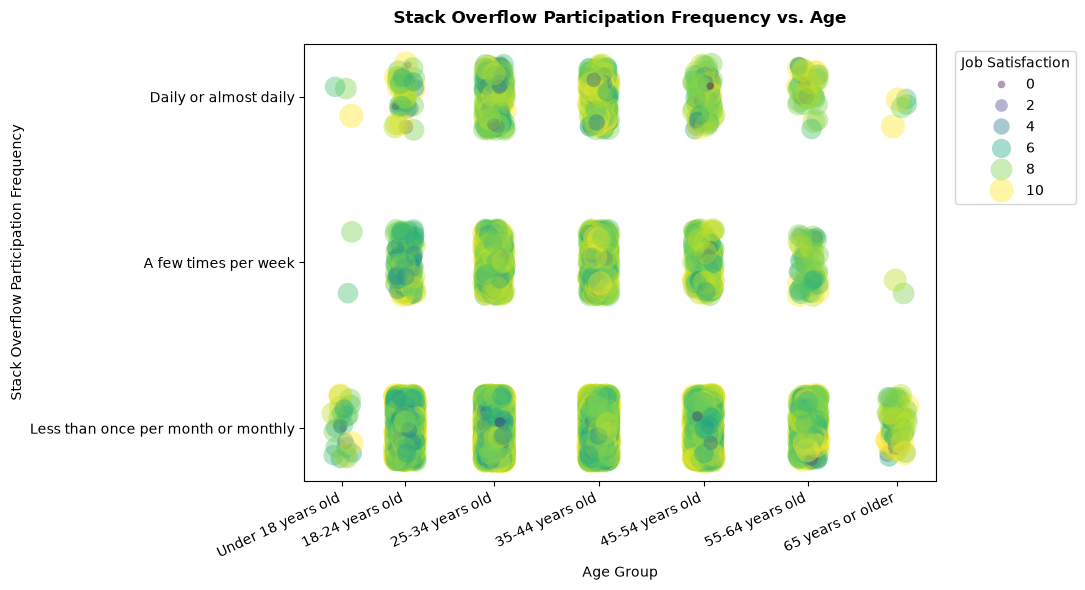

In [6]:
df_bubble = df[["Age", "SOPartFreq", "JobSat"]].dropna().copy()

# Cast columns to standard object dtype to prevent StringDtype error
df_bubble["Age"] = df_bubble["Age"].astype(object)
df_bubble["SOPartFreq"] = df_bubble["SOPartFreq"].astype(object)
df_bubble["JobSat"] = df_bubble["JobSat"].astype(object)

age_map = {
    "Under 18 years old": 15,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 68,
}
df_bubble["Age_Numeric"] = df_bubble["Age"].map(age_map)

part_freq_order = [
    "Never",
    "Less than once per month or monthly",
    "A few times per month",
    "A few times per week",
    "Daily or almost daily",
]
existing_categories = [
    c for c in part_freq_order if c in df_bubble["SOPartFreq"].unique()
]
freq_map = {cat: i for i, cat in enumerate(existing_categories)}
df_bubble["Freq_Num"] = df_bubble["SOPartFreq"].map(freq_map)

# Convert JobSat to standard numeric float
df_bubble["JobSat_Num"] = pd.to_numeric(
    df_bubble["JobSat"].astype(str), errors="coerce"
)

df_bubble = df_bubble.dropna(
    subset=["Age_Numeric", "Freq_Num", "JobSat_Num"]
).copy()

np.random.seed(42)
df_bubble["Age_Jitter"] = (
    df_bubble["Age_Numeric"].to_numpy(dtype=float)
    + np.random.uniform(-1.0, 1.0, size=len(df_bubble))
)
df_bubble["Freq_Jitter"] = (
    df_bubble["Freq_Num"].to_numpy(dtype=float)
    + np.random.uniform(-0.2, 0.2, size=len(df_bubble))
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.scatterplot(
    data=df_bubble,
    x="Age_Jitter",
    y="Freq_Jitter",
    size="JobSat_Num",
    hue="JobSat_Num",
    sizes=(30, 300),
    palette="viridis",
    alpha=0.4,
    edgecolor="none",
    ax=ax,
)

if existing_categories:
    ax.set_yticks(range(len(existing_categories)))
    ax.set_yticklabels(existing_categories)

ax.set_xticks(list(age_map.values()))
ax.set_xticklabels(list(age_map.keys()), rotation=25, ha="right")

plt.title(
    "Stack Overflow Participation Frequency vs. Age",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Age Group", fontsize=10)
plt.ylabel("Stack Overflow Participation Frequency", fontsize=10)
plt.legend(
    title="Job Satisfaction",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)

plt.tight_layout()
plt.show()

As we can see the respondents in the age group 25-54(the core workwing demografics) are pretty evenly distributed across all options of usage of stack overflow, 55-64 are less frequent on the site and the <18 and >65 are more likely to use it once a month or less. We observe that job satisfaction where present is spread across stack overflow usage so no real relationship can be observed.

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


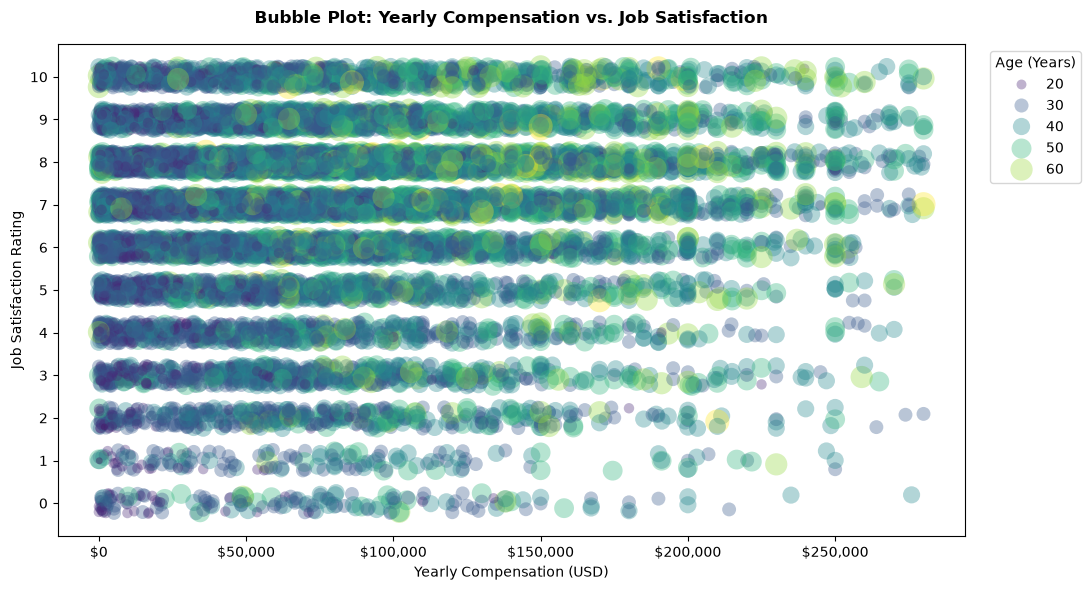

In [8]:
##Write your code here
df_bubble = df[["ConvertedCompYearly", "JobSat", "Age"]].dropna().copy()

df_bubble["Age"] = df_bubble["Age"].astype(object)
df_bubble["JobSat"] = df_bubble["JobSat"].astype(object)

age_map = {
    "Under 18 years old": 15,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 68,
}
df_bubble["Age_Numeric"] = df_bubble["Age"].map(age_map)

df_bubble["Comp_Num"] = pd.to_numeric(
    df_bubble["ConvertedCompYearly"], errors="coerce"
)
df_bubble["JobSat_Num"] = pd.to_numeric(
    df_bubble["JobSat"].astype(str), errors="coerce"
)

df_bubble = df_bubble.dropna(
    subset=["Comp_Num", "JobSat_Num", "Age_Numeric"]
).copy()

# Filter extreme salary outliers to keep the plot readable
q_high = df_bubble["Comp_Num"].quantile(0.98)
df_bubble = df_bubble[df_bubble["Comp_Num"] <= q_high].copy()

np.random.seed(42)
df_bubble["JobSat_Jitter"] = (
    df_bubble["JobSat_Num"].to_numpy(dtype=float)
    + np.random.uniform(-0.25, 0.25, size=len(df_bubble))
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.scatterplot(
    data=df_bubble,
    x="Comp_Num",
    y="JobSat_Jitter",
    size="Age_Numeric",
    hue="Age_Numeric",
    sizes=(25, 300),
    palette="viridis",
    alpha=0.35,
    edgecolor="none",
    ax=ax,
)

job_sat_unique = sorted(df_bubble["JobSat_Num"].unique())
ax.set_yticks(job_sat_unique)

ax.xaxis.set_major_formatter("${x:,.0f}")

plt.title(
    "Bubble Plot: Yearly Compensation vs. Job Satisfaction",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Yearly Compensation (USD)", fontsize=10)
plt.ylabel("Job Satisfaction Rating", fontsize=10)
plt.legend(
    title="Age (Years)",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)

plt.tight_layout()
plt.show()

**Compensation vs. Satisfaction Independence:** High-earning respondents (towards the right side of the x-axis) display job satisfaction ratings spread across the entire vertical scale, proving that higher pay does not directly shield developers from job dissatisfaction or guarantee high contentment.

**Age Diversity Across Income Tiers:** Larger bubbles (older developers) and smaller bubbles (younger developers) appear mixed together at both modest and high compensation levels, highlighting that salary progression isn't strictly tied to age alone (e.g., specialized skills or equity grants can elevate younger developers to high tiers).

**Summary Takeaway:** Job satisfaction is a multi-faceted metric driven by workplace culture, work-life balance, tech stack alignment, and autonomy, rather than being a direct linear outcome of compensation or age.

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



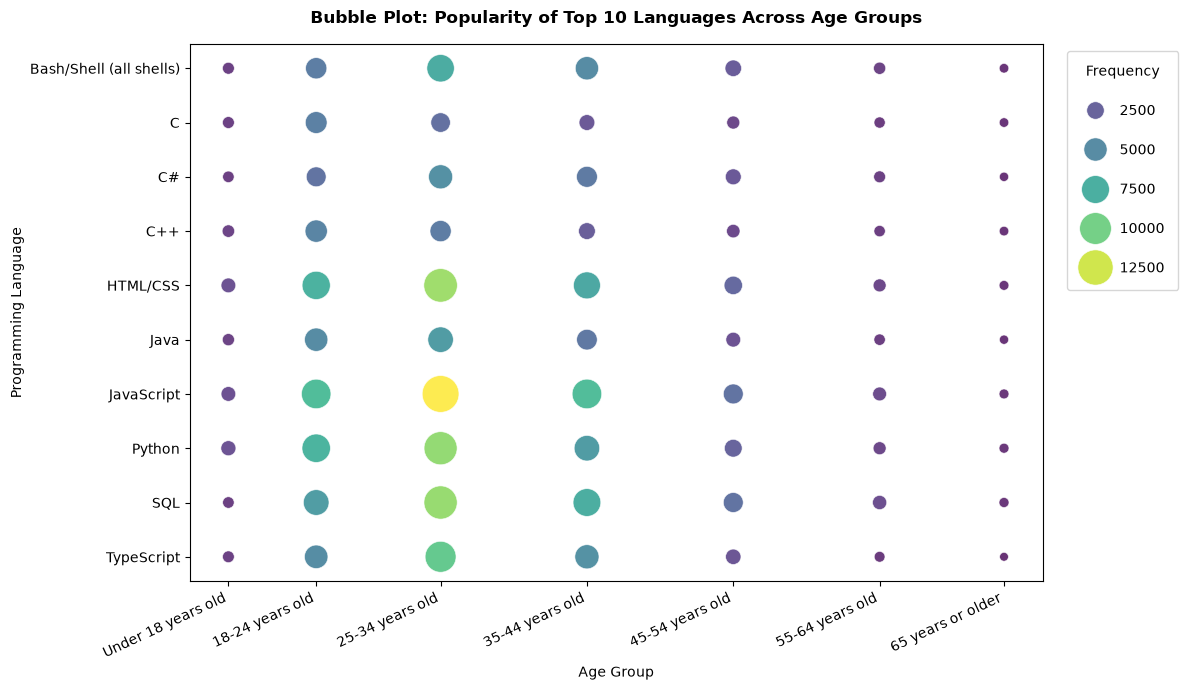

In [13]:
# Query LanguageHaveWorkedWith and Age from df
df_bubble = df[["LanguageHaveWorkedWith", "Age"]].dropna().copy()

df_bubble["Age"] = df_bubble["Age"].astype(object)
df_bubble["LanguageHaveWorkedWith"] = df_bubble[
    "LanguageHaveWorkedWith"
].astype(object)

age_map = {
    "Under 18 years old": 15,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 68,
}
df_bubble["Age_Numeric"] = df_bubble["Age"].map(age_map)

# Explode multi-select languages into individual rows
df_bubble["Language"] = df_bubble["LanguageHaveWorkedWith"].str.split(";")
df_exploded = df_bubble.explode("Language")
df_exploded["Language"] = df_exploded["Language"].str.strip()

# Get top 10 languages by frequency
top_10_langs = df_exploded["Language"].value_counts().head(10).index.tolist()
df_exploded = df_exploded[df_exploded["Language"].isin(top_10_langs)].copy()

# Group by Language and Age to count frequency
df_counts = (
    df_exploded.groupby(["Language", "Age", "Age_Numeric"])
    .size()
    .reset_index(name="Frequency")
)

fig, ax = plt.subplots(figsize=(12, 7))

# Map both size and hue to Frequency with a sequential palette
sns.scatterplot(
    data=df_counts,
    x="Age_Numeric",
    y="Language",
    size="Frequency",
    hue="Frequency",
    sizes=(40, 700),
    palette="viridis",
    alpha=0.8,
    edgecolor="white",
    linewidth=0.5,
    ax=ax,
)

ax.set_xticks(list(age_map.values()))
ax.set_xticklabels(list(age_map.keys()), rotation=25, ha="right")

plt.title(
    "Bubble Plot: Popularity of Top 10 Languages Across Age Groups",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Age Group", fontsize=10)
plt.ylabel("Programming Language", fontsize=10)

# Adjust legend spacing and markers to prevent overlapping
handles, labels = ax.get_legend_handles_labels()
plt.legend(
    handles=handles,
    labels=labels,
    title="Frequency",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    labelspacing=1.8,
    borderpad=1,
)

plt.tight_layout()
plt.show()

**Demographic Peak (25–34 Years):** The overwhelming majority of survey respondents cluster in this early-to-mid career age group, creating the largest bubble sizes across almost every language row.

**Core Stack Popularity:** JavaScript retains its position as the overall leader, closely matched by HTML/CSS, Python, and SQL—forming the standard web and data foundation across the industry.

**Language Diversity in the 25–34 Bracket:** Because respondent volume is concentrated here, this group shows the broadest spread across all 10 languages, indicating high adoption of both web technologies and systems programming.

**Niche Representation (<18 & 45+):** In the extreme age tiers, smaller sample sizes smooth out sharp differences between languages, showing balanced, lower-volume usage rather than a single dominant language.

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


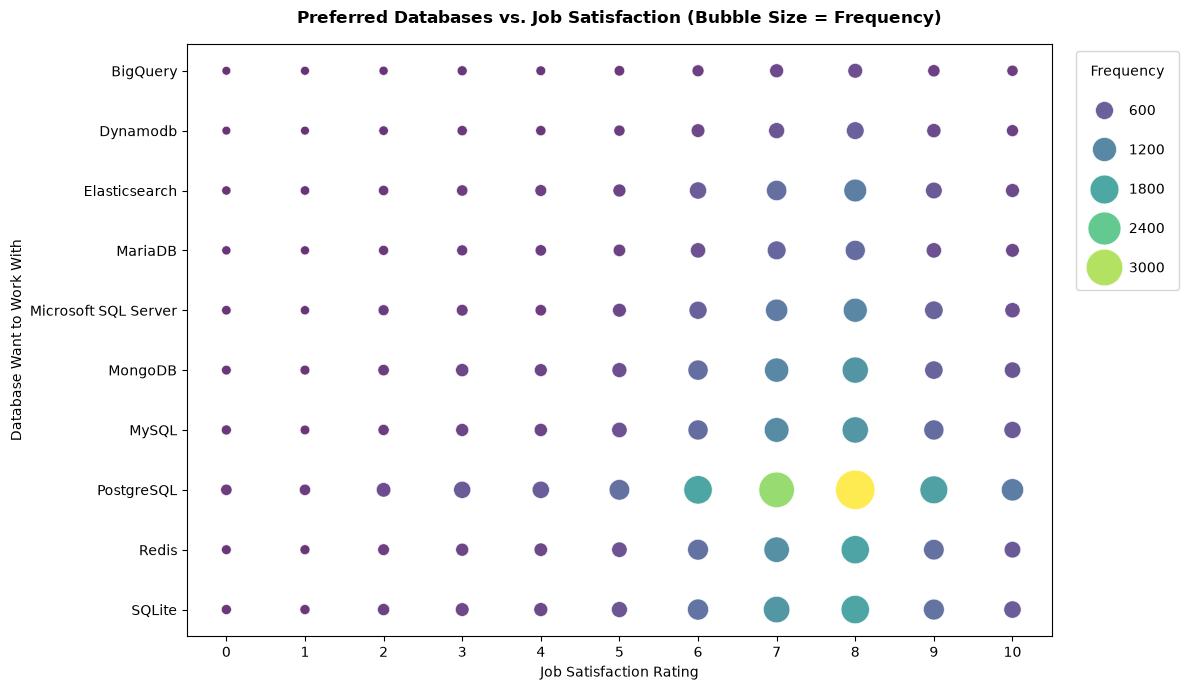

In [15]:
##Write your code here
# Query DatabaseWantToWorkWith, JobSat, and Age from df
df_bubble = df[["DatabaseWantToWorkWith", "JobSat", "Age"]].dropna().copy()

df_bubble["JobSat"] = df_bubble["JobSat"].astype(object)
df_bubble["DatabaseWantToWorkWith"] = df_bubble[
    "DatabaseWantToWorkWith"
].astype(object)

# Explode multi-select semi-colon separated databases into distinct rows
df_bubble["Database"] = df_bubble["DatabaseWantToWorkWith"].str.split(";")
df_exploded = df_bubble.explode("Database")
df_exploded["Database"] = df_exploded["Database"].str.strip()

# Clean and convert JobSat ratings to numeric
df_exploded["JobSat_Num"] = pd.to_numeric(
    df_exploded["JobSat"].astype(str), errors="coerce"
)
df_exploded = df_exploded.dropna(subset=["JobSat_Num"]).copy()

# Focus on the top 10 most preferred databases overall
top_10_dbs = df_exploded["Database"].value_counts().head(10).index.tolist()
df_exploded = df_exploded[df_exploded["Database"].isin(top_10_dbs)].copy()

# Group by Database and JobSat rating to count respondent frequency
df_counts = (
    df_exploded.groupby(["Database", "JobSat_Num"])
    .size()
    .reset_index(name="Frequency")
)

# Plot clean grid bubble chart
fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=df_counts,
    x="JobSat_Num",
    y="Database",
    size="Frequency",
    hue="Frequency",
    sizes=(40, 800),
    palette="viridis",
    alpha=0.8,
    edgecolor="white",
    linewidth=0.5,
    ax=ax,
)

# Ensure integer tick marks for Job Satisfaction ratings on X-axis
jobsat_unique = sorted(df_counts["JobSat_Num"].unique())
ax.set_xticks(jobsat_unique)

plt.title(
    "Preferred Databases vs. Job Satisfaction (Bubble Size = Frequency)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Job Satisfaction Rating", fontsize=10)
plt.ylabel("Database Want to Work With", fontsize=10)

# Adjust legend spacing and markers to avoid overlapping bubbles
handles, labels = ax.get_legend_handles_labels()
plt.legend(
    handles=handles,
    labels=labels,
    title="Frequency",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    labelspacing=1.8,
    borderpad=1,
)

plt.tight_layout()
plt.show()

**PostgreSQL Dominance:** PostgreSQL clearly commands the largest overall bubble volume across all ratings, reinforcing its status as the most sought-after database technology among developers.

**Skew Toward High Satisfaction:** The concentration of large bubbles clusters heavily on the higher end of the satisfaction scale (ratings 7–9, peaking at 8), showing that developers targeting modern relational databases like PostgreSQL generally report high job contentment.

**Secondary Tier:** Technologies like MySQL, SQLite, and MongoDB follow a similar distribution pattern, but with noticeably smaller bubble volumes across all satisfaction levels.

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


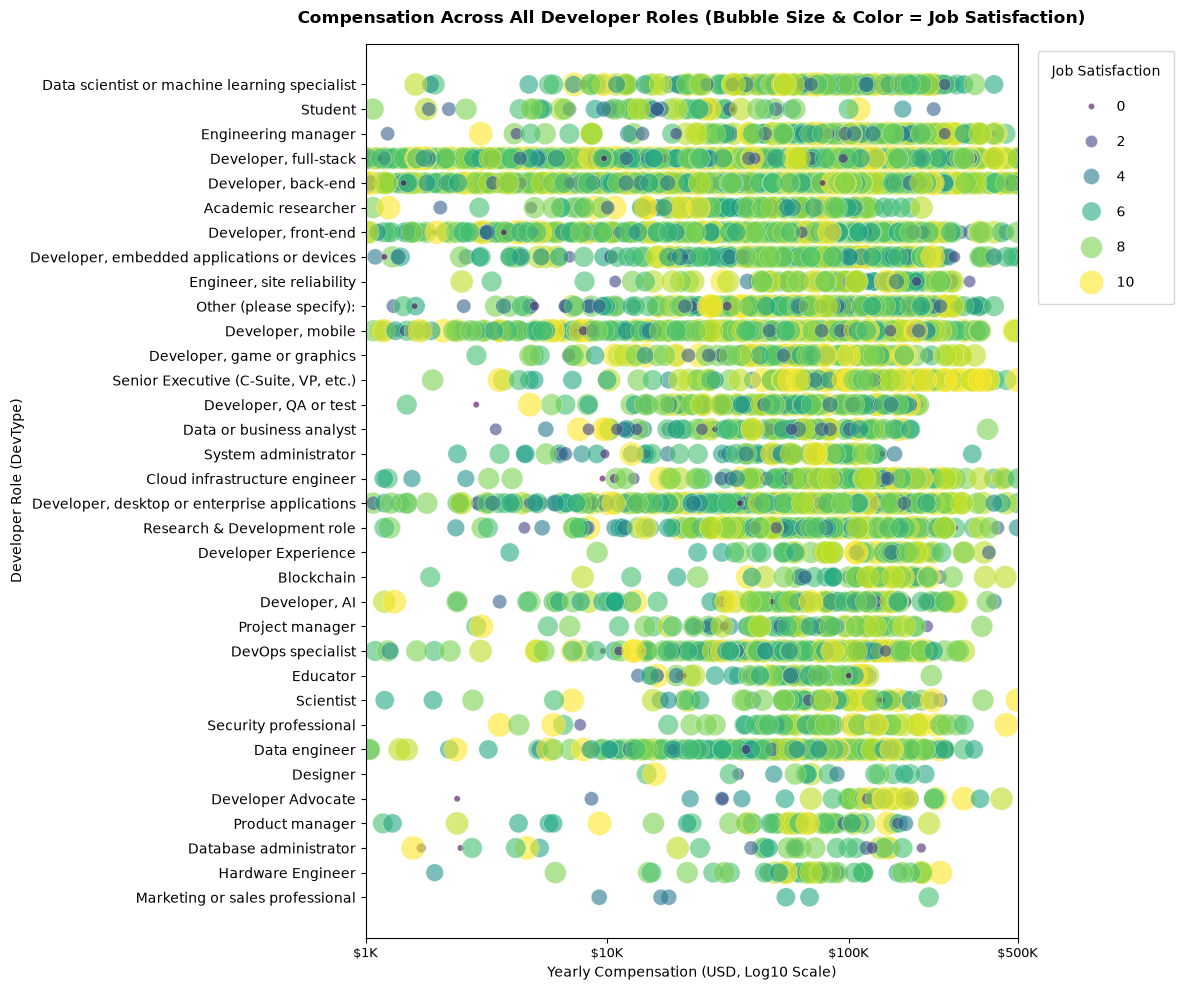

In [18]:
# Query DevType, ConvertedCompYearly, and JobSat from df
df_comp_role = df[["DevType", "ConvertedCompYearly", "JobSat"]].dropna().copy()

df_comp_role["DevType"] = df_comp_role["DevType"].astype(object)

# Explode multi-select semi-colon separated DevTypes into individual rows
df_comp_role["Role"] = df_comp_role["DevType"].str.split(";")
df_exploded = df_comp_role.explode("Role")
df_exploded["Role"] = df_exploded["Role"].str.strip()

# Convert JobSat to numeric float and clean invalid values
df_exploded["JobSat_Num"] = pd.to_numeric(
    df_exploded["JobSat"].astype(str), errors="coerce"
)
df_clean = df_exploded.dropna(subset=["ConvertedCompYearly", "JobSat_Num"]).copy()

# Filter out extreme compensation outliers for clearer visual distribution
df_clean = df_clean[
    (df_clean["ConvertedCompYearly"] >= 1000)
    & (df_clean["ConvertedCompYearly"] <= 500000)
]

# Calculate log10 compensation to handle scale variations across roles
df_clean["log_Comp"] = np.log10(df_clean["ConvertedCompYearly"])

# Render Bubble Plot across ALL developer roles
fig, ax = plt.subplots(figsize=(12, 10))

sns.scatterplot(
    data=df_clean,
    x="log_Comp",
    y="Role",
    size="JobSat_Num",
    hue="JobSat_Num",
    sizes=(20, 300),
    palette="viridis",
    alpha=0.6,
    edgecolor="white",
    linewidth=0.3,
    ax=ax,
)

# Set hardcoded x-ticks and human-readable currency labels
fixed_ticks = [3, 4, 5, 5.7]
fixed_labels = ["$1K", "$10K", "$100K", "$500K"]

ax.set_xticks(fixed_ticks)
ax.set_xticklabels(fixed_labels, fontsize=9)
ax.set_xlim(3, 5.7)

plt.title(
    "Compensation Across All Developer Roles (Bubble Size & Color = Job Satisfaction)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Yearly Compensation (USD, Log10 Scale)", fontsize=10)
plt.ylabel("Developer Role (DevType)", fontsize=10)

# Legend configuration with vertical spacing to prevent overlapping
handles, labels = ax.get_legend_handles_labels()
plt.legend(
    handles=handles,
    labels=labels,
    title="Job Satisfaction",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    labelspacing=1.5,
    borderpad=1,
)

plt.tight_layout()
plt.show()

**Job Satisfaction Independence:** Job satisfaction spans the entire scale (from lowest to highest ratings) across all developer roles regardless of whether compensation sits at `$10K` or `$500K`. High compensation does not automatically guarantee high satisfaction, nor does lower compensation preclude it.

**Core Role Clustering:** The densest concentrations of data points naturally align with primary software engineering disciplines—namely Backend, Frontend, Full-stack, Mobile, and Enterprise Application developers—reflecting where the vast majority of industry workforce volume sits.

**Broad Spread Across Roles:** While niche or specialized roles (like Security Specialists or Engineering Managers) display fewer data points, their satisfaction ratings show the exact same  variance as the major core developer groups.

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


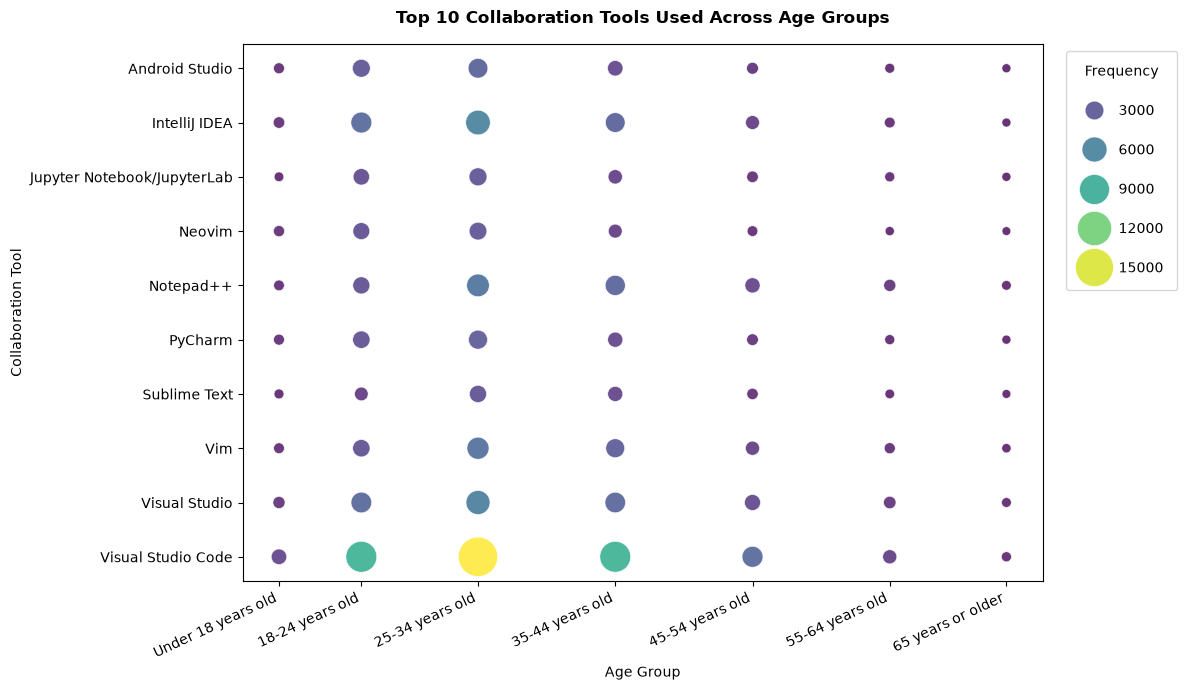

In [20]:
##Write your code here
# Query NEWCollabToolsHaveWorkedWith and Age from df
df_collab = df[["NEWCollabToolsHaveWorkedWith", "Age"]].dropna().copy()

df_collab["Age"] = df_collab["Age"].astype(object)
df_collab["NEWCollabToolsHaveWorkedWith"] = df_collab[
    "NEWCollabToolsHaveWorkedWith"
].astype(object)

# Chronological ordering for Age categories
age_map = {
    "Under 18 years old": 15,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 68,
}
df_collab["Age_Numeric"] = df_collab["Age"].map(age_map)

# Explode multi-select semi-colon separated collaboration tools into individual rows
df_collab["Tool"] = df_collab["NEWCollabToolsHaveWorkedWith"].str.split(";")
df_exploded = df_collab.explode("Tool")
df_exploded["Tool"] = df_exploded["Tool"].str.strip()

# Focus on the top 10 most popular collaboration tools overall
top_10_tools = df_exploded["Tool"].value_counts().head(10).index.tolist()
df_exploded = df_exploded[df_exploded["Tool"].isin(top_10_tools)].copy()

# Group by Tool and Age to calculate frequency
df_counts = (
    df_exploded.groupby(["Tool", "Age", "Age_Numeric"])
    .size()
    .reset_index(name="Frequency")
)

# Plot Bubble Chart
fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=df_counts,
    x="Age_Numeric",
    y="Tool",
    size="Frequency",
    hue="Frequency",
    sizes=(40, 800),
    palette="viridis",
    alpha=0.8,
    edgecolor="white",
    linewidth=0.5,
    ax=ax,
)

ax.set_xticks(list(age_map.values()))
ax.set_xticklabels(list(age_map.keys()), rotation=25, ha="right")

plt.title(
    "Top 10 Collaboration Tools Used Across Age Groups",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Age Group", fontsize=10)
plt.ylabel("Collaboration Tool", fontsize=10)

# Legend configuration with vertical spacing to prevent marker overlaps
handles, labels = ax.get_legend_handles_labels()
plt.legend(
    handles=handles,
    labels=labels,
    title="Frequency",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    labelspacing=1.8,
    borderpad=1,
)

plt.tight_layout()
plt.show()

Visual Studio Code leads by a massive margin across every age category, peaking heavily in the 25–34 age group where overall respondent density is highest.

Across the entire dataset, VS Code commands the largest bubble volumes, followed by traditional collaboration and IDE platforms like IntelliJ.

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



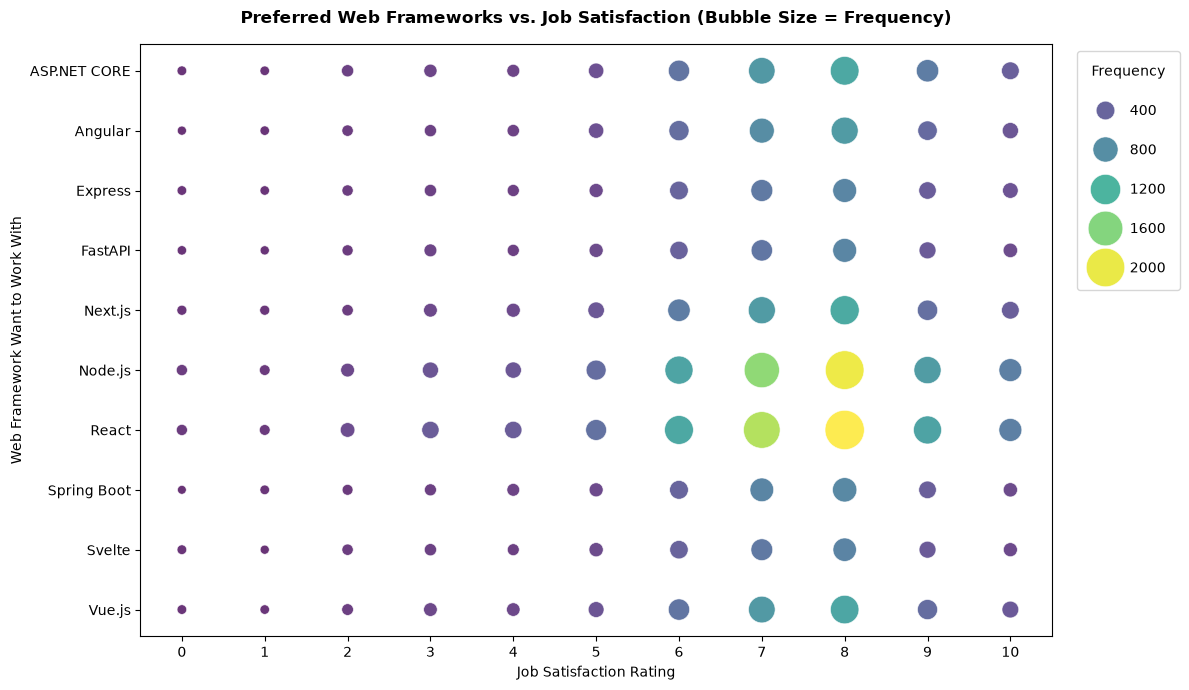

In [22]:
##Write your code here
# Query WebframeWantToWorkWith and JobSat from df
df_webframe = df[["WebframeWantToWorkWith", "JobSat"]].dropna().copy()

df_webframe["JobSat"] = df_webframe["JobSat"].astype(object)
df_webframe["WebframeWantToWorkWith"] = df_webframe[
    "WebframeWantToWorkWith"
].astype(object)

# Explode multi-select semi-colon separated frameworks into individual rows
df_webframe["Framework"] = df_webframe["WebframeWantToWorkWith"].str.split(";")
df_exploded = df_webframe.explode("Framework")
df_exploded["Framework"] = df_exploded["Framework"].str.strip()

# Clean and convert JobSat ratings to numeric
df_exploded["JobSat_Num"] = pd.to_numeric(
    df_exploded["JobSat"].astype(str), errors="coerce"
)
df_exploded = df_exploded.dropna(subset=["JobSat_Num"]).copy()

# Focus on top 10 most preferred web frameworks overall
top_10_frameworks = (
    df_exploded["Framework"].value_counts().head(10).index.tolist()
)
df_exploded = df_exploded[df_exploded["Framework"].isin(top_10_frameworks)].copy()

# Group by Framework and JobSat to compute respondent frequency
df_counts = (
    df_exploded.groupby(["Framework", "JobSat_Num"])
    .size()
    .reset_index(name="Frequency")
)

# Render Bubble Plot
fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=df_counts,
    x="JobSat_Num",
    y="Framework",
    size="Frequency",
    hue="Frequency",
    sizes=(40, 800),
    palette="viridis",
    alpha=0.8,
    edgecolor="white",
    linewidth=0.5,
    ax=ax,
)

# Set clean integer tick marks for Job Satisfaction scale
jobsat_unique = sorted(df_counts["JobSat_Num"].unique())
ax.set_xticks(jobsat_unique)

plt.title(
    "Preferred Web Frameworks vs. Job Satisfaction (Bubble Size = Frequency)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Job Satisfaction Rating", fontsize=10)
plt.ylabel("Web Framework Want to Work With", fontsize=10)

# Configure legend spacing to prevent overlap
handles, labels = ax.get_legend_handles_labels()
plt.legend(
    handles=handles,
    labels=labels,
    title="Frequency",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    labelspacing=1.8,
    borderpad=1,
)

plt.tight_layout()
plt.show()

Node.js and React.js consistently lead as the most sought-after web technologies, with respondent volume clustering heavily around high job satisfaction levels (7 and 8 out of 10).

This demonstrates a strong alignment between modern JavaScript/TypeScript ecosystem dominance and positive developer sentiment.

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



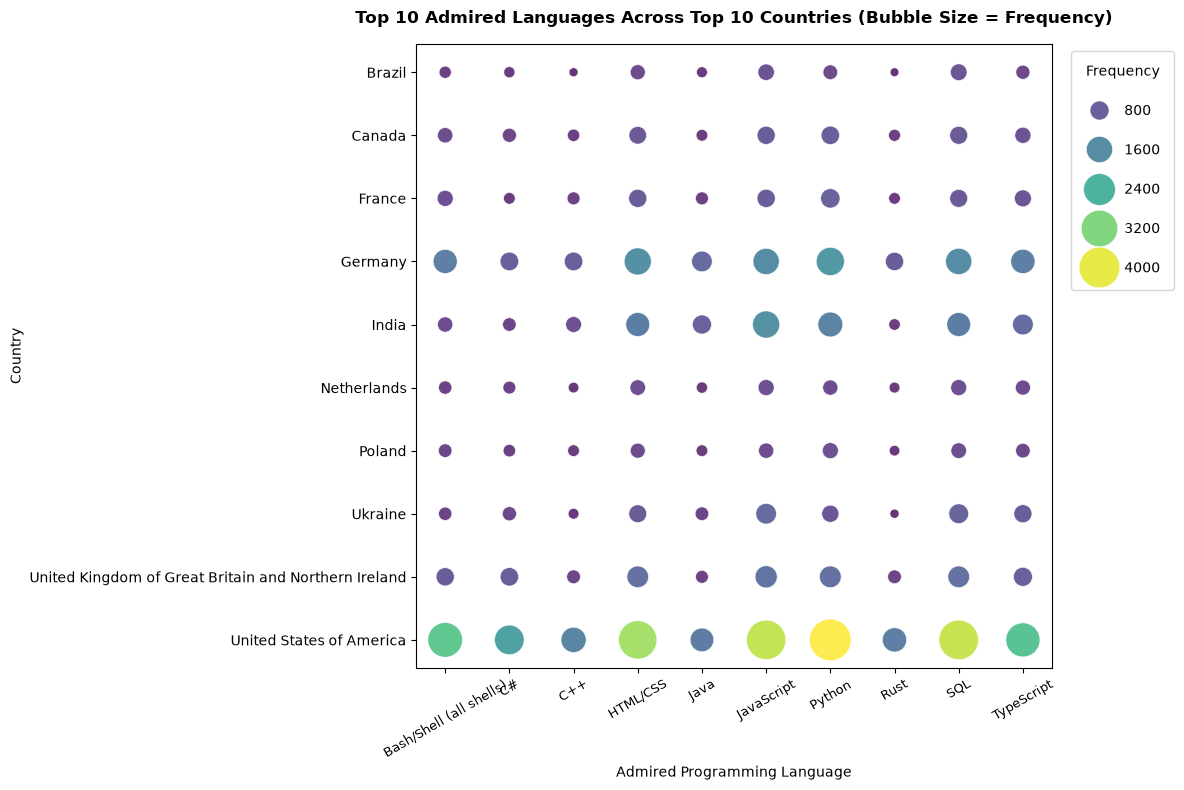

In [23]:
##Write your code here
# Query LanguageAdmired and Country from df
df_admired = df[["LanguageAdmired", "Country"]].dropna().copy()

df_admired["Country"] = df_admired["Country"].astype(object)
df_admired["LanguageAdmired"] = df_admired["LanguageAdmired"].astype(object)

# Explode multi-select semi-colon separated languages into individual rows
df_admired["Language"] = df_admired["LanguageAdmired"].str.split(";")
df_exploded = df_admired.explode("Language")
df_exploded["Language"] = df_exploded["Language"].str.strip()

# Filter for Top 10 Countries and Top 10 Languages overall
top_10_countries = (
    df_exploded["Country"].value_counts().head(10).index.tolist()
)
top_10_languages = (
    df_exploded["Language"].value_counts().head(10).index.tolist()
)

df_filtered = df_exploded[
    (df_exploded["Country"].isin(top_10_countries))
    & (df_exploded["Language"].isin(top_10_languages))
].copy()

# Group by Country and Language to compute admiration frequency
df_counts = (
    df_filtered.groupby(["Country", "Language"])
    .size()
    .reset_index(name="Frequency")
)

# Render Bubble Plot
fig, ax = plt.subplots(figsize=(12, 8))

sns.scatterplot(
    data=df_counts,
    x="Language",
    y="Country",
    size="Frequency",
    hue="Frequency",
    sizes=(40, 900),
    palette="viridis",
    alpha=0.8,
    edgecolor="white",
    linewidth=0.5,
    ax=ax,
)

ax.tick_params(axis="x", rotation=30, labelsize=9)

plt.title(
    "Top 10 Admired Languages Across Top 10 Countries (Bubble Size = Frequency)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Admired Programming Language", fontsize=10)
plt.ylabel("Country", fontsize=10)

# Configure legend spacing to prevent overlap
handles, labels = ax.get_legend_handles_labels()
plt.legend(
    handles=handles,
    labels=labels,
    title="Frequency",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    labelspacing=1.8,
    borderpad=1,
)

plt.tight_layout()
plt.show()

**Universal Language Stack:** Python, JavaScript, TypeScript, and HTML/CSS hold the largest bubble sizes across every single country in the top 10—from the US and UK to India, Germany, and Brazil.

**Global Tech Parity:** Modern developer admiration is largely language-driven rather than region-dependent. Developer interest in languages like Rust and Go shows proportional popularity across both high-volume and lower-volume survey markets.

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
